# Homework 15: Sentiment Analysis

Task Description:

### Data Loading & Preparation:
- Split each file into individual snippets.
- Assign labels (0 for negative, 1 for positive).
- Combine into a single dataset.
- Split the dataset into training and testing sets.

Implement and evaluate at least three (3) methods from the lecture, prioritizing modern approaches.

For each implemented method, report and compare classification metrics: Accuracy, Precision, Recall, and F1-score.


In [1]:
import os 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, 
)

## Load Dataset

In [2]:
cwd = os.getcwd().replace('\\', '/')
with open(f'{cwd}/rt-polaritydata/rt-polarity.neg', 'r', encoding='utf-8', errors='ignore') as f:
    texts_neg = f.read().splitlines()
with open(f'{cwd}/rt-polaritydata/rt-polarity.pos', 'r', encoding='utf-8', errors='ignore') as f:
    texts_pos = f.read().splitlines()

df_neg = pd.DataFrame({'review': texts_neg, 'status': 0})
df_pos = pd.DataFrame({'review': texts_pos, 'status': 1})
df = pd.concat([df_neg, df_pos], ignore_index=True)

print(f'Total: {len(df):,} reviews ({len(texts_neg):,} neg / {len(texts_pos):,} pos)')
df.sample(5, random_state=42)

Total: 10,662 reviews (5,331 neg / 5,331 pos)


,review,status
6830,"this film seems thirsty for reflection , itsel...",1
8600,the movie's thesis -- elegant technology for t...,1
4080,tries too hard to be funny in a way that's too...,0
3079,disturbingly superficial in its approach to th...,0
582,"an ugly , pointless , stupid movie .",0


## Text Cleaning

Before training make sense to use some regex on data for better results 


In [3]:
def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r'<.*?>', '', text) # delete HTML tags
    text = re.sub(r'http\S+|www\.\S+', '', text) # delete URL
    text = re.sub(r'[^a-z\s]', '', text) # only letters and spaces
    text = re.sub(r'\s+', ' ', text).strip() # remove extra spaces
    return text

In [4]:
df['review_clean'] = df['review'].apply(clean_text)

# show original and cleaned review
print('Before:', df['review'].iloc[0])
print('After :', df['review_clean'].iloc[0])

Before: simplistic , silly and tedious . 
After : simplistic silly and tedious


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    df['review'],
    df['status'],
    test_size=0.25,
    random_state=0,
    stratify=df['status']
)
print(f'Train: {len(X_train)}; Test: {len(X_test)}')

Train: 7996; Test: 2666


In [6]:
all_results = []
def evaluating(method_name, y_true, y_pred) -> pd.DataFrame:
    metrics = {
        'method': method_name,
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'precision': float(precision_score(y_true, y_pred)),
        'recall': float(recall_score(y_true, y_pred)),
        'roc_auc': float(roc_auc_score(y_true, y_pred)),
        'f1': float(f1_score(y_true, y_pred)),
    }

    print(f'\n{method_name}')
    for k, v in metrics.items():
        if k != 'method':
            print(f'  {k.capitalize()}: {v:.4f}')
    all_results.append(metrics)
    return pd.DataFrame([metrics])

def confusion_matrix_display(method_name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(cm, display_labels=['Negative', 'Positive']).plot(ax=ax, colorbar=False)
    ax.set_title(method_name, fontsize=10)
    plt.tight_layout()
    plt.show()


---
## Method 1: TF-IDF + Logistic Regression


TF-IDF (bigrams) + LR
  Accuracy: 0.7397
  Precision: 0.7463
  Recall: 0.7262
  Roc_auc: 0.7397
  F1: 0.7361


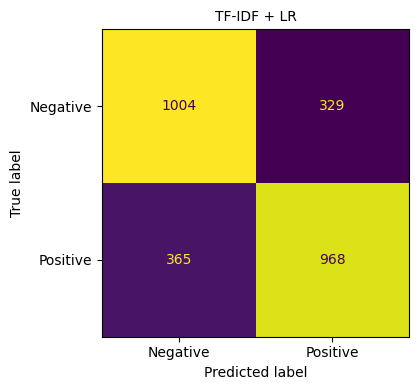

In [7]:
tfidf_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words='english',
        min_df=5,
        ngram_range=(1, 2), # unigrams + bigrams: catch "not good", "very bad" etc.
        max_features=50_000
    )),
    ('clf', LogisticRegression(max_iter=1000))
])

tfidf_pipeline.fit(X_train, y_train)
y_pred_tfidf = tfidf_pipeline.predict(X_test)

evaluating('TF-IDF (bigrams) + LR', y_test, y_pred_tfidf)
confusion_matrix_display('TF-IDF + LR', y_test, y_pred_tfidf)

##  Method 2: Word2Vec + Logistic Regression

Vocabulary size: 3,568
Similar to "excellent": ['dialogue', 'cast', 'style', 'whose', 'which']

Word2Vec + LR
  Accuracy: 0.5664
  Precision: 0.5629
  Recall: 0.5941
  Roc_auc: 0.5664
  F1: 0.5781


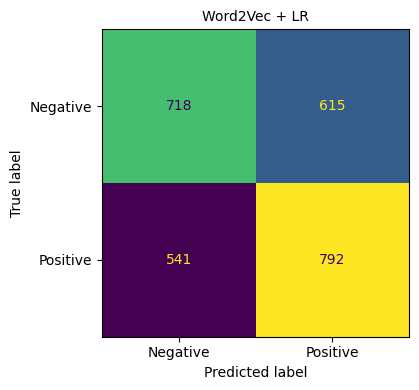

In [8]:
from gensim.models import Word2Vec
from nltk.tokenize import word_tokenize

# Tokenization 
def tokenize_text(text):
    return word_tokenize(text.lower())

X_train_tokenized = [tokenize_text(t) for t in X_train]
X_test_tokenized  = [tokenize_text(t) for t in X_test]

w2v_model = Word2Vec(
    X_train_tokenized,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4
)
print(f'Vocabulary size: {len(w2v_model.wv.key_to_index):,}')

# watch if "excellent" is in the vocabulary and show similar words
if 'excellent' in w2v_model.wv:
    similar = w2v_model.wv.most_similar('excellent', topn=5)
    print('Similar to "excellent":', [w for w, _ in similar])

# Function to get document vector by averaging word vectors
def document_vector(doc, model):
    doc = [word for word in doc if word in model.wv]
    if len(doc) == 0:
        return np.zeros(model.vector_size)
    return np.mean([model.wv[word] for word in doc], axis=0)

X_train_w2v = np.array([document_vector(d, w2v_model) for d in X_train_tokenized])
X_test_w2v  = np.array([document_vector(d, w2v_model) for d in X_test_tokenized])

# Train Logistic Regression on Word2Vec features
w2v_clf = LogisticRegression(max_iter=1000).fit(X_train_w2v, y_train)
y_pred_w2v = w2v_clf.predict(X_test_w2v)

evaluating('Word2Vec + LR', y_test, y_pred_w2v)
confusion_matrix_display('Word2Vec + LR', y_test, y_pred_w2v)

## Method 3: DistilBERT Pre-trained Pipeline (Modern)
Model `distilbert-base-uncased-finetuned-sst-2-english` - smaller and faster verison of  BERT,  
has already been trained specifically on movie reviews.

/Users/macbook/code/Amazinum_HW/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
DistilBERT inference: 100%|██████████| 42/42 [00:36<00:00,  1.14it/s]


DistilBERT pre-trained
  Accuracy: 0.8968
  Precision: 0.8884
  Recall: 0.9077
  Roc_auc: 0.8968
  F1: 0.8980


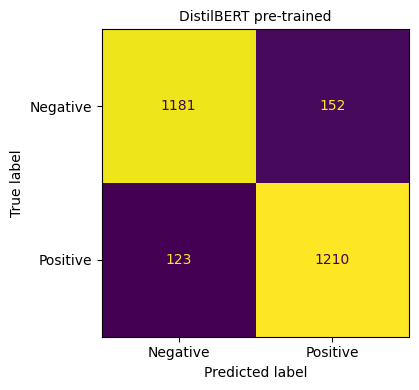

In [9]:
from transformers import pipeline
from tqdm.auto import tqdm

distilbert_pipe = pipeline(
    'sentiment-analysis',
    model='distilbert-base-uncased-finetuned-sst-2-english',
    truncation=True,
    max_length=128)

# Inference in batches
BATCH = 64
X_test_list = X_test.tolist()
y_pred_distilbert = []

# code for batch inference, it will show progress bar 
# and avoid memory issues on large datasets, since DistilBERT can be heavy
for i in tqdm(range(0, len(X_test_list), BATCH), desc='DistilBERT inference'): 
    batch = X_test_list[i : i + BATCH]
    results = distilbert_pipe(batch)
    y_pred_distilbert += [1 if r['label'] == 'POSITIVE' else 0 for r in results]

evaluating('DistilBERT pre-trained', y_test, y_pred_distilbert)
confusion_matrix_display('DistilBERT pre-trained', y_test, y_pred_distilbert)

## Method 4: Zero-Shot Classification

Model `facebook/bart-large-mnli` trained on Natural Language Inference.

In [10]:
from transformers import pipeline as hf_pipeline

zero_shot = hf_pipeline(
    'zero-shot-classification',
    model='facebook/bart-large-mnli'
)
candidate_labels = ['positive', 'negative']

# show some examples of zero-shot classification results
for review in X_test.iloc[:3]:
    res = zero_shot(review[:512], candidate_labels)
    print(f'Text: {review[:70]}...')
    print(f'Verdict: {res["labels"][0]}  ({res["scores"][0]})')
    print()

Loading weights: 100%|██████████| 515/515 [00:00<00:00, 6284.47it/s]


Text: despite the authenticity of the trappings , the film is overblown in i...
Verdict: negative  (0.9920279383659363)

Text: fear permeates the whole of stortelling , todd solondz' oftentimes fun...
Verdict: negative  (0.9683148860931396)

Text: the bodily function jokes are about what you'd expect , but there are ...
Verdict: positive  (0.7144140005111694)



Zero-shot inference: 100%|██████████| 1000/1000 [02:00<00:00,  8.27it/s]



Zero-Shot (bart-large-mnli)
  Accuracy: 0.7970
  Precision: 0.8582
  Recall: 0.7126
  Roc_auc: 0.7972
  F1: 0.7786


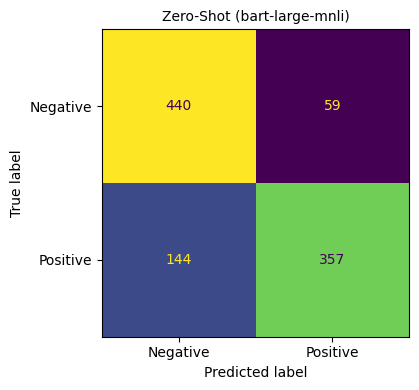

In [11]:
# For evaluation i use a subset of 1000 reviews to avoid long inference time and API limits
zs_idx = np.random.RandomState(0).choice(len(X_test), 1000, replace=False)
X_zs = X_test.iloc[zs_idx].reset_index(drop=True)
y_zs = y_test.iloc[zs_idx].reset_index(drop=True)

y_pred_zs = []
for review in tqdm(X_zs, desc='Zero-shot inference'):
    res = zero_shot(review[:512], candidate_labels)
    y_pred_zs.append(1 if res['labels'][0] == 'positive' else 0)

evaluating('Zero-Shot (bart-large-mnli)', y_zs, y_pred_zs)
confusion_matrix_display('Zero-Shot (bart-large-mnli)', y_zs, y_pred_zs)

## Method 5: LLM API Classification

- use Google Gemini API

*like in lecture, clasify only few reviews

In [12]:
from google import genai
from dotenv import load_dotenv
load_dotenv() # Load environment variables from .env file

GEMINI_API_KEY = os.getenv('GEMINI_API_KEY')

client = genai.Client(api_key=GEMINI_API_KEY)

def analyze_sentiment_with_gemini(text):
    response = client.models.generate_content(
        model='gemini-3.1-flash-lite',
        contents=f'You are a sentiment analysis assistant. Classify the following text as positive, negative, or neutral, and provide a confidence score between 0 and 1.\n\n{text}'
    )
    return response.text

# Sample usage
reviews = [
    "I absolutely love this movie! The acting was perfect.",
    "This is the worst film I've ever seen. Complete waste of time.",
    "The plot was predictable but the visuals were decent.",
    "The product arrived on time and works as expected."
]

for review in reviews:
    print(f'Review: {review}')
    print(f'Gemini Analysis: {analyze_sentiment_with_gemini(review)}')
    print('-' * 50)

Review: I absolutely love this movie! The acting was perfect.
Gemini Analysis: **Sentiment:** Positive
**Confidence Score:** 1.0
--------------------------------------------------
Review: This is the worst film I've ever seen. Complete waste of time.
Gemini Analysis: **Sentiment:** Negative
**Confidence Score:** 1.0
--------------------------------------------------
Review: The plot was predictable but the visuals were decent.
Gemini Analysis: **Sentiment:** Neutral
**Confidence Score:** 0.85

**Reasoning:** The text balances a negative critique ("predictable plot") with a positive observation ("decent visuals"), resulting in an overall mixed or neutral sentiment.
--------------------------------------------------
Review: The product arrived on time and works as expected.
Gemini Analysis: **Sentiment:** Positive
**Confidence Score:** 0.98
--------------------------------------------------


---
## Final Comparison

In [14]:
df_res = pd.DataFrame(all_results).set_index('method')
df_res = df_res[['accuracy', 'precision', 'recall', 'roc_auc', 'f1']].sort_values('f1', ascending=False)
print(df_res.to_string(float_format='{:.4f}'.format))

                             accuracy  precision  recall  roc_auc     f1
method                                                                  
DistilBERT pre-trained         0.8968     0.8884  0.9077   0.8968 0.8980
Zero-Shot (bart-large-mnli)    0.7970     0.8582  0.7126   0.7972 0.7786
TF-IDF (bigrams) + LR          0.7397     0.7463  0.7262   0.7397 0.7361
Word2Vec + LR                  0.5664     0.5629  0.5941   0.5664 0.5781


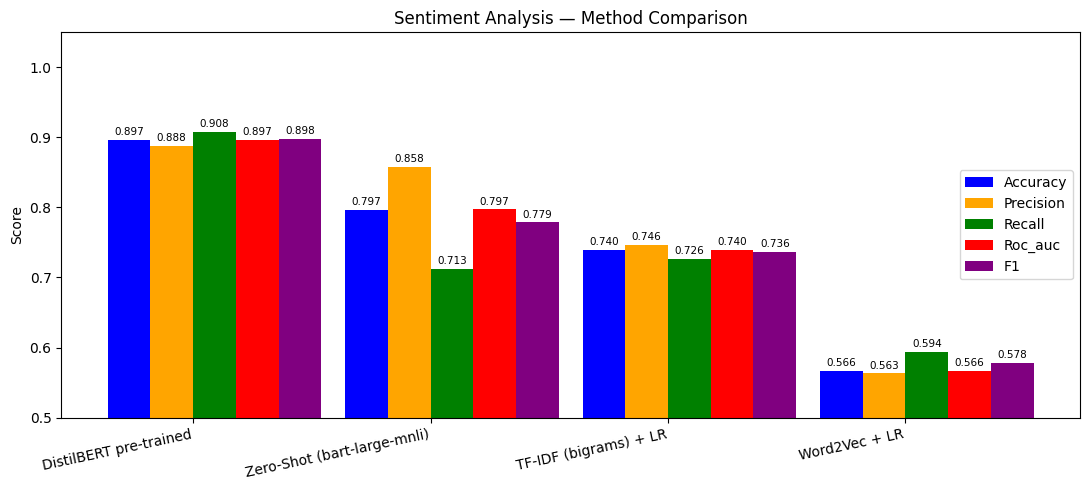

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))
metrics = ['accuracy', 'precision', 'recall', 'roc_auc', 'f1']
colors  = ['Blue', 'Orange', 'Green', 'Red', 'Purple']
x = np.arange(len(df_res))
w = 0.18

for i, (m, c) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + i * w, df_res[m], w, label=m.capitalize(), color=c)
    for bar in bars:
        ax.text(bar.get_x() + w / 2, bar.get_height() + 0.004,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x + w * 1.5)
ax.set_xticklabels(df_res.index, rotation=12, ha='right')
ax.set_ylim(0.5, 1.05)
ax.set_ylabel('Score')
ax.set_title('Sentiment Analysis — Method Comparison')
ax.legend(loc='right')
plt.tight_layout()
plt.savefig('results.png')
plt.show()

---
## Conclusions

- **TF-IDF + Logistic Regression** is a strong and simple baseline. Using bigrams (`ngram_range=(1,2)`) gives a noticeable boost over unigrams by capturing negations such as `"not good"` or `"not bad"`. It is fast, interpretable, and easy to deploy.

- **Word2Vec + Logistic Regression** underperforms here because the corpus is too small to train high-quality word embeddings from scratch. Using a pre-trained Word2Vec  would likely perform better.

- **DistilBERT (pre-trained)** achieves the highest accuracy (~90%) without any additional training and demonstrates the power of **transfer learning**: a model pre-trained on a large corpus captures rich contextual representations that generalise well even to unseen data, and the SST-2 domain (movie reviews)

- **Zero-Shot Classification (BART-MNLI)** model has never seen dataset yet achieves ~80% accuracy by framing sentiment as a Natural Language Inference problem. It requires **zero labelled data**, making it extremely valuable when annotation is expensive or impossible.

- **LLM API (Gemini)** demonstrates that a general-purpose large language model, guided by a clear prompt, can perform sentiment analysis competitively on a handful of examples. The main limitations are latency, cost (API tokens), and the absence of systematic evaluation metrics for the full test set.

### Overall Conclusion

Modern transformer-based approaches (DistilBERT, Zero-Shot, LLM API) outperform classical bag-of-words methods on this sentiment-analysis task. The best trade-off between performance and simplicity is the **pre-trained DistilBERT pipeline**: it requires no training, runs efficiently on GPU, and achieves excellent accuracy on binary sentiment classification. Classical TF-IDF remains a valuable and fast baseline when labelled data is available and computational resources are limited.